<a href="https://colab.research.google.com/github/jovicma/euro2024-ace-lab-analysis/blob/main/notebooks/02_game_state_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install statsbombpy -q

import pandas as pd
import numpy as np
from statsbombpy import sb
import warnings
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.7 MB/s eta 0:00:00


In [2]:
print("Extraindo partidas da Euro 2024...")
df_matches = sb.matches(competition_id=55, season_id=282)

# Lista para guardar os chutes com a informação do estado do jogo
shots_with_state = []

print("Processando a linha do tempo dos jogos (Isso pode levar um minuto)...")

for idx, match in df_matches.iterrows():
    match_id = match['match_id']
    home_team = match['home_team']
    away_team = match['away_team']

    # Baixa os eventos do jogo
    events = sb.events(match_id=match_id)

    # Filtra apenas os chutes
    if 'Shot' not in events['type'].values:
        continue

    shots = events[events['type'] == 'Shot'].copy()

    # Identifica todos os gols da partida (Excluindo disputas de pênalti pós-jogo)
    # A Statsbomb mapeia o 'period' (1=1º tempo, 2=2º tempo, 3/4=Prorrogação, 5=Penaltis)
    goals = shots[(shots['shot_outcome'] == 'Goal') & (shots['period'] < 5)].copy()

    # Para cada chute no jogo, vamos ver qual era o placar naquele minuto específico
    for _, shot in shots[shots['period'] < 5].iterrows():
        shot_minute = shot['minute']
        shot_team = shot['team']

        # Conta quantos gols o time da casa e o visitante fizeram ANTES do minuto deste chute
        home_goals_before = len(goals[(goals['team'] == home_team) & (goals['minute'] < shot_minute)])
        away_goals_before = len(goals[(goals['team'] == away_team) & (goals['minute'] < shot_minute)])

        # Define o estado do jogo para o time que está chutando
        if shot_team == home_team:
            team_goals = home_goals_before
            opp_goals = away_goals_before
        else:
            team_goals = away_goals_before
            opp_goals = home_goals_before

        if team_goals > opp_goals:
            game_state = 'Ganhando'
        elif team_goals < opp_goals:
            game_state = 'Perdendo'
        else:
            game_state = 'Empatando'

        # Salva as informações relevantes
        shots_with_state.append({
            'match_id': match_id,
            'team': shot_team,
            'minute': shot_minute,
            'xg': shot.get('shot_statsbomb_xg', 0),
            'game_state': game_state
        })

df_game_state = pd.DataFrame(shots_with_state)
print(f"Total de finalizações processadas com Estado do Jogo: {len(df_game_state)}")

Extraindo partidas da Euro 2024...
Processando a linha do tempo dos jogos (Isso pode levar um minuto)...
Total de finalizações processadas com Estado do Jogo: 1316


In [15]:
print("Recalculando Minutos e xG/90 com Correção de Períodos e Pênaltis...")

time_data = []
xg_data = []

for idx, match in df_matches.iterrows():
    match_id = match['match_id']
    home_team = match['home_team']
    away_team = match['away_team']

    events = sb.events(match_id=match_id)

    # --- CORREÇÃO 1: Remover disputa de pênaltis (period 5) ---
    events = events[events['period'] < 5].copy()

    # --- CORREÇÃO 2: Ordenar por período para evitar o "Volta no Tempo" ---
    events['time_sec'] = events['minute'] * 60 + events['second']
    events = events.sort_values(by=['period', 'time_sec']).reset_index(drop=True)

    # Reconstruindo placar dinâmico (com gols contra)
    is_home_shot_goal = (events['team'] == home_team) & (events['type'] == 'Shot') & (events['shot_outcome'] == 'Goal')
    is_home_own_goal = (events['team'] == away_team) & (events['type'] == 'Own Goal Against')
    is_away_shot_goal = (events['team'] == away_team) & (events['type'] == 'Shot') & (events['shot_outcome'] == 'Goal')
    is_away_own_goal = (events['team'] == home_team) & (events['type'] == 'Own Goal Against')

    events['is_home_goal'] = (is_home_shot_goal | is_home_own_goal).astype(int)
    events['is_away_goal'] = (is_away_shot_goal | is_away_own_goal).astype(int)
    events['home_score'] = events['is_home_goal'].cumsum().shift(1).fillna(0)
    events['away_score'] = events['is_away_goal'].cumsum().shift(1).fillna(0)
    events['home_gd'] = events['home_score'] - events['away_score']

    # --- CORREÇÃO 3: Calcular duração isolada por período (1º T, 2º T, Prorrogações) ---
    events['duration_sec'] = events.groupby('period')['time_sec'].shift(-1) - events['time_sec']
    events['duration_sec'] = events['duration_sec'].fillna(0)

    state_durations = events.groupby('home_gd')['duration_sec'].sum() / 60.0

    for gd, mins in state_durations.items():
        if mins <= 0: continue
        h_state = 'Ganhando' if gd > 0 else ('Perdendo' if gd < 0 else 'Empatando')
        a_state = 'Perdendo' if gd > 0 else ('Ganhando' if gd < 0 else 'Empatando')

        time_data.append({'team': home_team, 'game_state': h_state, 'minutes': mins})
        time_data.append({'team': away_team, 'game_state': a_state, 'minutes': mins})

    # Extraindo o xG apenas de chutes normais de jogo
    for team in [home_team, away_team]:
        team_shots = events[(events['team'] == team) & (events['type'] == 'Shot')]
        for _, shot in team_shots.iterrows():
            gd = shot['home_gd'] if team == home_team else -shot['home_gd']
            state = 'Ganhando' if gd > 0 else ('Perdendo' if gd < 0 else 'Empatando')
            xg = shot.get('shot_statsbomb_xg', 0)
            if pd.isna(xg): xg = 0

            xg_data.append({'team': team, 'game_state': state, 'xg': xg})

# Consolidando Tempo e xG
df_time = pd.DataFrame(time_data).groupby(['team', 'game_state'])['minutes'].sum().reset_index()
df_xg = pd.DataFrame(xg_data).groupby(['team', 'game_state'])['xg'].sum().reset_index()

state_analysis = pd.merge(df_time, df_xg, on=['team', 'game_state'], how='left').fillna(0)

# NORMALIZAÇÃO: Calculando xG gerado a cada 90 minutos
# Adicionamos uma "trava": se a equipe jogou menos de 15 minutos naquele estado, o xG/90 não é calculado (fica NaN)
# para evitar distorções de amostra pequena (ex: 1 chute em 2 minutos = 45 xG/90).
MINUTOS_MINIMOS = 15

state_analysis['xg_p90'] = np.where(state_analysis['minutes'] >= MINUTOS_MINIMOS,
                                    (state_analysis['xg'] / state_analysis['minutes']) * 90, np.nan)

# Pivotando a tabela para leitura do xG/90
pivot_xg90 = state_analysis.pivot(index='team', columns='game_state', values='xg_p90')

for estado in ['Ganhando', 'Empatando', 'Perdendo']:
    if estado not in pivot_xg90.columns: pivot_xg90[estado] = np.nan

pivot_xg90 = pivot_xg90[['Ganhando', 'Empatando', 'Perdendo']].round(2)

print("\nTabela de xG por 90 min (Cenários com menos de 15 min aparecem como NaN):")
display(pivot_xg90.sort_values(by='Empatando', ascending=False))

Recalculando Minutos e xG/90 com Correção de Períodos e Pênaltis...

Tabela de xG por 90 min (Cenários com menos de 15 min aparecem como NaN):


game_state,Ganhando,Empatando,Perdendo
team,,,
Croatia,0.26,1.62,2.56
Turkey,0.86,1.62,0.90
Spain,1.24,1.51,0.81
Portugal,1.60,1.36,2.12
France,1.57,1.23,0.57
Slovakia,0.29,1.21,1.76
Germany,1.67,1.19,1.78
Hungary,NaN,1.13,0.92
Austria,1.46,1.09,1.60


In [14]:
print("Calculando posse relativa por estado do jogo (Código Corrigido e Otimizado)...")

match_possession = []

for idx, match in df_matches.iterrows():
    match_id = match['match_id']
    home_team = match['home_team']
    away_team = match['away_team']

    events = sb.events(match_id=match_id)

    # --- CORREÇÃO 1: Garantir ordem cronológica exata ---
    events['time_sec'] = events['minute'] * 60 + events['second']
    events = events.sort_values(by=['time_sec']).reset_index(drop=True)

    # --- CORREÇÃO 2: Mapear Gols Normais e Gols Contra (Own Goals) ---
    # Gol do mandante = Chute dele que entrou OU Gol contra do visitante
    is_home_shot_goal = (events['team'] == home_team) & (events['type'] == 'Shot') & (events['shot_outcome'] == 'Goal')
    is_home_own_goal = (events['team'] == away_team) & (events['type'] == 'Own Goal Against')

    is_away_shot_goal = (events['team'] == away_team) & (events['type'] == 'Shot') & (events['shot_outcome'] == 'Goal')
    is_away_own_goal = (events['team'] == home_team) & (events['type'] == 'Own Goal Against')

    events['is_home_goal'] = (is_home_shot_goal | is_home_own_goal).astype(int)
    events['is_away_goal'] = (is_away_shot_goal | is_away_own_goal).astype(int)

    # Placar cumulativo antes do evento atual acontecer (shift)
    events['home_score'] = events['is_home_goal'].cumsum().shift(1).fillna(0)
    events['away_score'] = events['is_away_goal'].cumsum().shift(1).fillna(0)

    events['home_gd'] = events['home_score'] - events['away_score']

    # Filtrar passes apenas do tempo regulamentar/prorrogação
    passes = events[(events['type'] == 'Pass') & (events['period'] < 5)]

    pass_counts = passes.groupby(['home_gd', 'team']).size().unstack(fill_value=0).reset_index()

    if home_team not in pass_counts.columns: pass_counts[home_team] = 0
    if away_team not in pass_counts.columns: pass_counts[away_team] = 0

    for _, row in pass_counts.iterrows():
        gd = row['home_gd']
        h_passes = row[home_team]
        a_passes = row[away_team]
        total_passes = h_passes + a_passes

        if total_passes == 0: continue

        if gd > 0:
            h_state, a_state = 'Ganhando', 'Perdendo'
        elif gd < 0:
            h_state, a_state = 'Perdendo', 'Ganhando'
        else:
            h_state, a_state = 'Empatando', 'Empatando'

        match_possession.append({'team': home_team, 'state': h_state, 'passes_for': h_passes, 'passes_against': a_passes})
        match_possession.append({'team': away_team, 'state': a_state, 'passes_for': a_passes, 'passes_against': h_passes})

df_poss = pd.DataFrame(match_possession)

# Agregação Final e Cálculo da Posse (%)
agg_poss = df_poss.groupby(['team', 'state']).sum().reset_index()
agg_poss['posse_%'] = (agg_poss['passes_for'] / (agg_poss['passes_for'] + agg_poss['passes_against'])) * 100

pivot_poss = agg_poss.pivot(index='team', columns='state', values='posse_%').round(1)

# Segurança para as colunas
for estado in ['Ganhando', 'Empatando', 'Perdendo']:
    if estado not in pivot_poss.columns:
        pivot_poss[estado] = np.nan

pivot_poss = pivot_poss[['Ganhando', 'Empatando', 'Perdendo']]

passes_totais = agg_poss.groupby('team')['passes_for'].sum()
pivot_poss['Passes Totais no Torneio'] = passes_totais

pivot_poss = pivot_poss.sort_values(by='Empatando', ascending=False)

display(pivot_poss)

Calculando posse relativa por estado do jogo (Código Corrigido e Otimizado)...


state,Ganhando,Empatando,Perdendo,Passes Totais no Torneio
team,,,,
Portugal,53.5,66.7,71.7,3870.0
Spain,54.4,61.2,71.2,4335.0
Germany,65.4,59.5,62.1,3402.0
Turkey,37.3,58.4,48.6,2445.0
Croatia,31.2,58.3,62.6,1785.0
England,40.6,56.6,70.3,4540.0
France,40.4,53.5,42.6,3453.0
Austria,45.0,53.3,58.6,2070.0
Scotland,20.7,52.0,29.1,1232.0


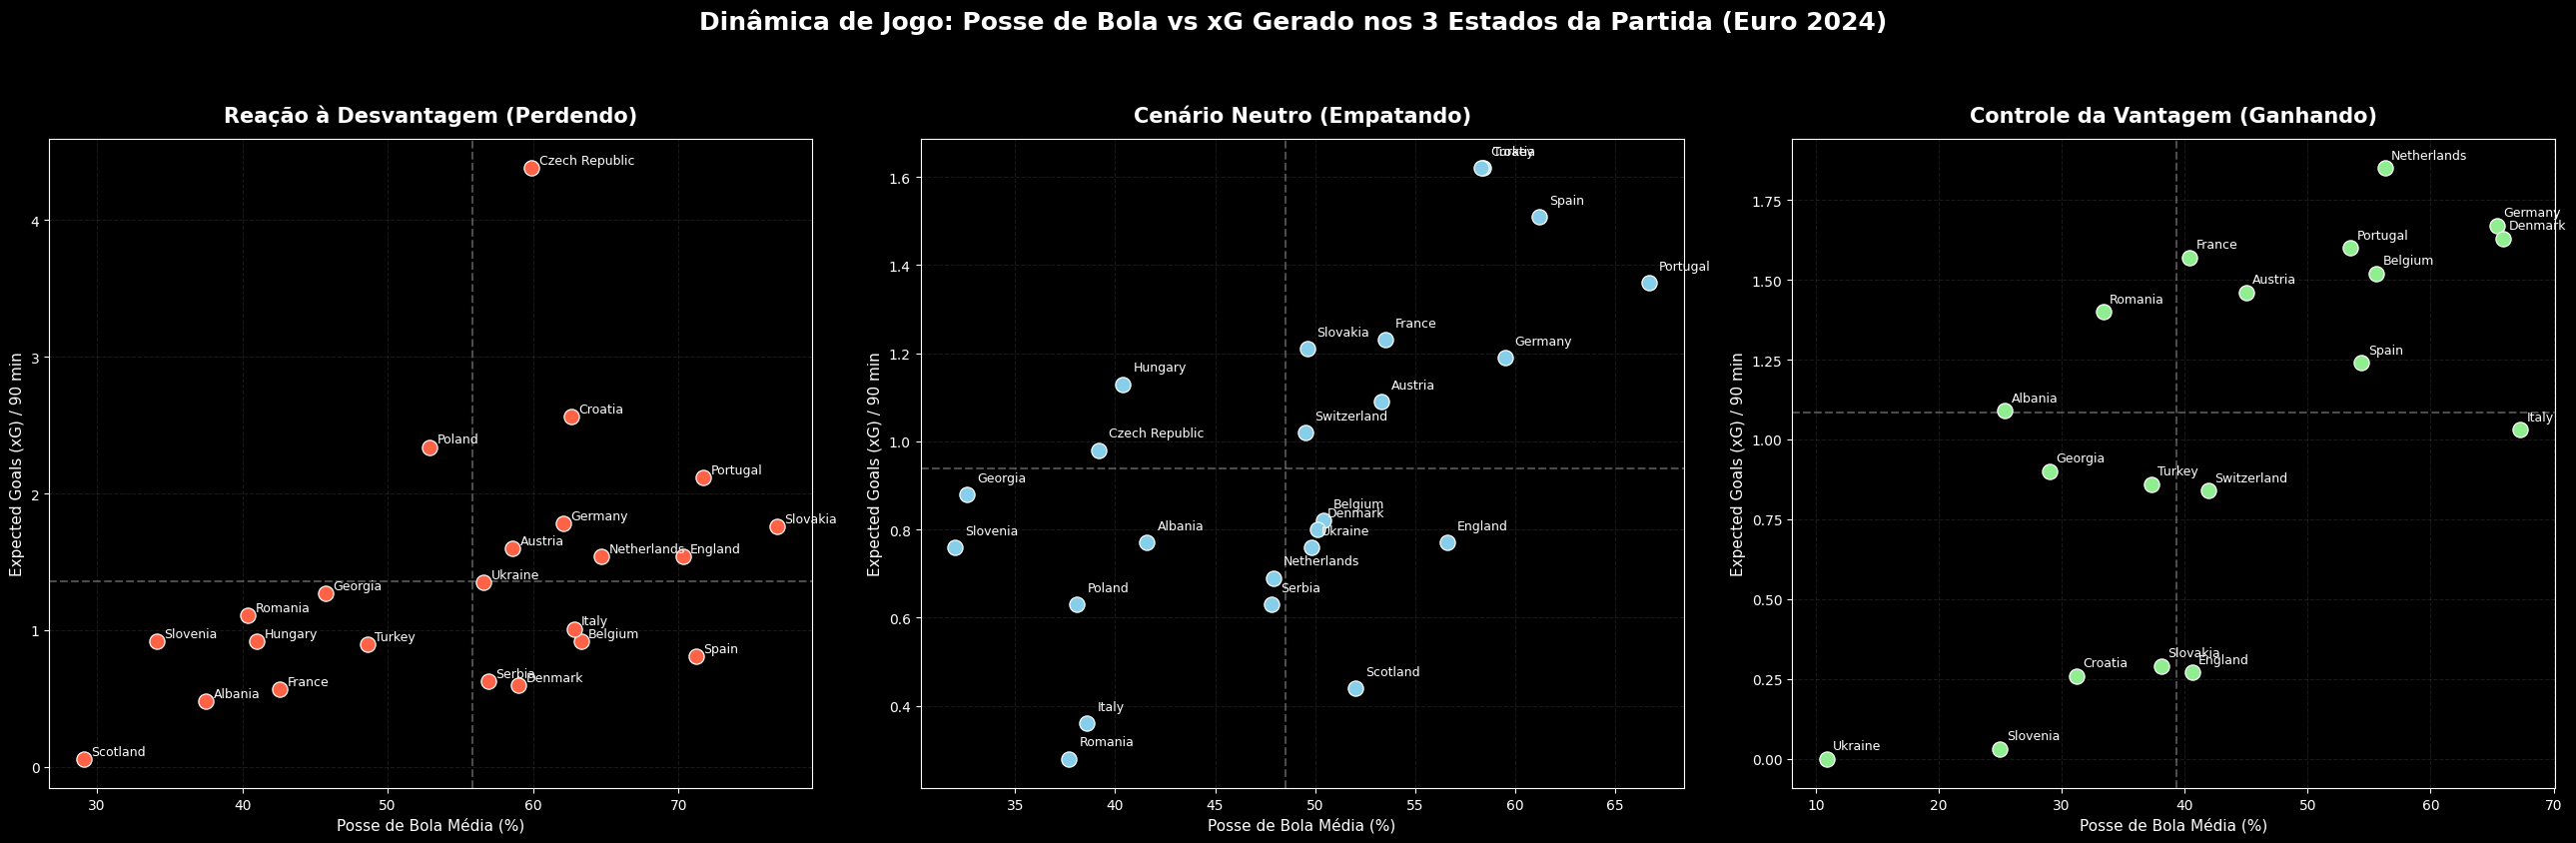

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mesclando as tabelas de Posse e xG/90
df_plot = pivot_poss.copy().reset_index()
df_plot = df_plot.rename(columns={'Ganhando': 'Poss_Ganhando', 'Empatando': 'Poss_Empatando', 'Perdendo': 'Poss_Perdendo'})

# Trazendo os valores de xG/90 da outra tabela
xg90_reset = pivot_xg90.reset_index()
df_plot = pd.merge(df_plot, xg90_reset, on='team', how='left')
df_plot = df_plot.rename(columns={'Ganhando': 'xG90_Ganhando', 'Empatando': 'xG90_Empatando', 'Perdendo': 'xG90_Perdendo'})

# Plotagem: Agora com 3 gráficos (1 linha, 3 colunas)
plt.style.use("dark_background")
fig, axes = plt.subplots(1, 3, figsize=(26, 8))

# --- GRÁFICO 1: PERDENDO (Desvantagem) ---
sns.scatterplot(data=df_plot, x="Poss_Perdendo", y="xG90_Perdendo", ax=axes[0], color="tomato", edgecolor="white", s=120, zorder=3)
if len(df_plot[df_plot['Poss_Perdendo'] > 0]) > 0:
    media_poss_p = df_plot[df_plot['Poss_Perdendo'] > 0]['Poss_Perdendo'].mean()
    media_xg_p = df_plot[df_plot['xG90_Perdendo'] > 0]['xG90_Perdendo'].mean()
    axes[0].axvline(media_poss_p, linestyle="--", color="white", alpha=0.3)
    axes[0].axhline(media_xg_p, linestyle="--", color="white", alpha=0.3)
    for i in range(df_plot.shape[0]):
        if df_plot['Poss_Perdendo'][i] > 0:
            axes[0].text(df_plot['Poss_Perdendo'][i] + 0.5, df_plot['xG90_Perdendo'][i] + 0.03, df_plot['team'][i], fontsize=9, color='white')

axes[0].set_title("Reação à Desvantagem (Perdendo)", fontsize=15, fontweight="bold", pad=12)
axes[0].set_xlabel("Posse de Bola Média (%)", fontsize=11)
axes[0].set_ylabel("Expected Goals (xG) / 90 min", fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.1)

# --- GRÁFICO 2: EMPATANDO (Cenário Neutro / Baseline) ---
sns.scatterplot(data=df_plot, x="Poss_Empatando", y="xG90_Empatando", ax=axes[1], color="skyblue", edgecolor="white", s=120, zorder=3)
media_poss_e = df_plot[df_plot['Poss_Empatando'] > 0]['Poss_Empatando'].mean()
media_xg_e = df_plot[df_plot['xG90_Empatando'] > 0]['xG90_Empatando'].mean()
axes[1].axvline(media_poss_e, linestyle="--", color="white", alpha=0.3)
axes[1].axhline(media_xg_e, linestyle="--", color="white", alpha=0.3)
for i in range(df_plot.shape[0]):
    if df_plot['Poss_Empatando'][i] > 0:
        axes[1].text(df_plot['Poss_Empatando'][i] + 0.5, df_plot['xG90_Empatando'][i] + 0.03, df_plot['team'][i], fontsize=9, color='white')

axes[1].set_title("Cenário Neutro (Empatando)", fontsize=15, fontweight="bold", pad=12)
axes[1].set_xlabel("Posse de Bola Média (%)", fontsize=11)
axes[1].set_ylabel("Expected Goals (xG) / 90 min", fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.1)

# --- GRÁFICO 3: GANHANDO (Vantagem) ---
sns.scatterplot(data=df_plot, x="Poss_Ganhando", y="xG90_Ganhando", ax=axes[2], color="lightgreen", edgecolor="white", s=120, zorder=3)
if len(df_plot[df_plot['Poss_Ganhando'] > 0]) > 0:
    media_poss_g = df_plot[df_plot['Poss_Ganhando'] > 0]['Poss_Ganhando'].mean()
    media_xg_g = df_plot[df_plot['xG90_Ganhando'] > 0]['xG90_Ganhando'].mean()
    axes[2].axvline(media_poss_g, linestyle="--", color="white", alpha=0.3)
    axes[2].axhline(media_xg_g, linestyle="--", color="white", alpha=0.3)
    for i in range(df_plot.shape[0]):
        if df_plot['Poss_Ganhando'][i] > 0:
            axes[2].text(df_plot['Poss_Ganhando'][i] + 0.5, df_plot['xG90_Ganhando'][i] + 0.03, df_plot['team'][i], fontsize=9, color='white')

axes[2].set_title("Controle da Vantagem (Ganhando)", fontsize=15, fontweight="bold", pad=12)
axes[2].set_xlabel("Posse de Bola Média (%)", fontsize=11)
axes[2].set_ylabel("Expected Goals (xG) / 90 min", fontsize=11)
axes[2].grid(True, linestyle="--", alpha=0.1)

# Ajuste global
fig.suptitle("Dinâmica de Jogo: Posse de Bola vs xG Gerado nos 3 Estados da Partida (Euro 2024)", fontsize=18, fontweight="bold", color="white", y=1.05)
plt.tight_layout()
plt.savefig("gamestate_full_analysis.png", dpi=300, bbox_inches="tight")
plt.show()